In [1]:
def p(a):
    print(a)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    df= pd.read_csv('titanic.csv')
except FileNotFoundError:
    sns.load_dataset('titanic').to_csv('titanic.csv', index=False)
    df = pd.read_csv('titanic.csv')

In [3]:
df.head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
p(df.shape)
p(df.info())

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   gender       891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None


In [5]:
df.describe().round(1)

,survived,pclass,age,sibsp,parch,fare
count,891.0,891.0,714.0,891.0,891.0,891.0
mean,0.4,2.3,29.7,0.5,0.4,32.2
std,0.5,0.8,14.5,1.1,0.8,49.7
min,0.0,1.0,0.4,0.0,0.0,0.0
25%,0.0,2.0,20.1,0.0,0.0,7.9
50%,0.0,3.0,28.0,0.0,0.0,14.5
75%,1.0,3.0,38.0,1.0,0.0,31.0
max,1.0,3.0,80.0,8.0,6.0,512.3


In [6]:
df.isna().sum()

survived         0
pclass           0
gender           0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
p(df['gender'].value_counts())

gender
male      577
female    314
Name: count, dtype: int64


In [8]:
p(df['survived'].value_counts())
print('max:',int(df['fare'].max()))
a = int(df['age'].mean())
print('AVG:',a)
print(df.isna().sum()[df.isna().sum()>0])

survived
0    549
1    342
Name: count, dtype: int64
max: 512
AVG: 29
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


**Our questions for today:**

1. How many passengers survived?
2. Did **women** survive more than **men**?
3. Did **ticket class** matter?
4. Did **children** survive more than adults?
5. Which column is **most related** to survival?

In [43]:
df['age'].median()

np.float64(28.0)

In [45]:
df['age'].median()

np.float64(28.0)

In [47]:
df['embark_town'].mode()[0]

'Southampton'

**cleaning data**


droping cloumns and fill age with median and embarked with mode or most common values

In [9]:
df = df.drop(columns=['deck', 'alive', 'class','embark_town', 'who','adult_male'])

df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [10]:
df.isna().sum()

survived    0
pclass      0
gender      0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

In [11]:
df['family_size'] = df['sibsp']+df['parch']+1
df['age_group'] = np.where(df['age']<16, "Child", "Adult")
df['is_female'] = np.where(df['gender'] == 'female', 1,0)

df.head(10)

,survived,pclass,gender,age,sibsp,parch,fare,embarked,alone,family_size,age_group,is_female
0,0,3,male,22.0,1,0,7.2500,S,False,2,Adult,0
1,1,1,female,38.0,1,0,71.2833,C,False,2,Adult,1
2,1,3,female,26.0,0,0,7.9250,S,True,1,Adult,1
3,1,1,female,35.0,1,0,53.1000,S,False,2,Adult,1
4,0,3,male,35.0,0,0,8.0500,S,True,1,Adult,0
5,0,3,male,28.0,0,0,8.4583,Q,True,1,Adult,0
6,0,1,male,54.0,0,0,51.8625,S,True,1,Adult,0
7,0,3,male,2.0,3,1,21.0750,S,False,5,Child,0
8,1,3,female,27.0,0,2,11.1333,S,False,3,Adult,1
9,1,2,female,14.0,1,0,30.0708,C,False,2,Child,1


### ✏️ QUICK CHECK 3: Clean check

1) Print `df.shape` after cleaning. How many columns now?
2) Print `df["age_group"].value_counts()`. How many children are there?
3) Make a new column `fare_per_person` = `fare` / `family_size`. Print the 5 highest values. (Hint: `sort_values(ascending=False).head()`.)

In [55]:
df.shape

(891, 12)

In [60]:
df['age_group'].value_counts()

age_group
Adult    808
Child     83
Name: count, dtype: int64

In [12]:
df['fare_per_person'] = df['fare']/df['family_size']
print(df['fare_per_person'].sort_values(ascending=False).head())

737    512.3292
258    512.3292
679    256.1646
716    227.5250
380    227.5250
Name: fare_per_person, dtype: float64


In [13]:
df.shape

(891, 13)

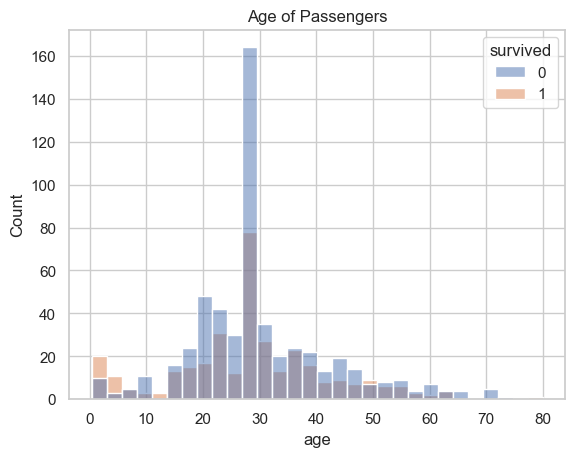

In [15]:
sns.histplot(data=df, x='age',bins=30, hue='survived')
plt.title("Age of Passengers")
plt.show()

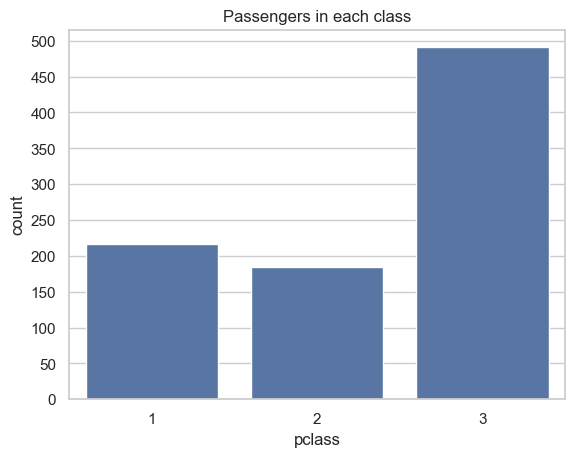

In [20]:
sns.countplot(data=df, x='pclass')
plt.yticks(range(0, 501, 50))
plt.title("Passengers in each class")
plt.show()

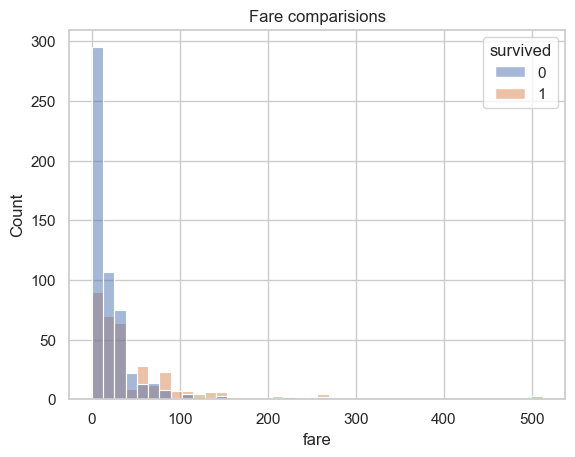

In [23]:
sns.histplot(data=df, x='fare', bins=40,hue='survived')
plt.title("Fare comparisions")
plt.show()


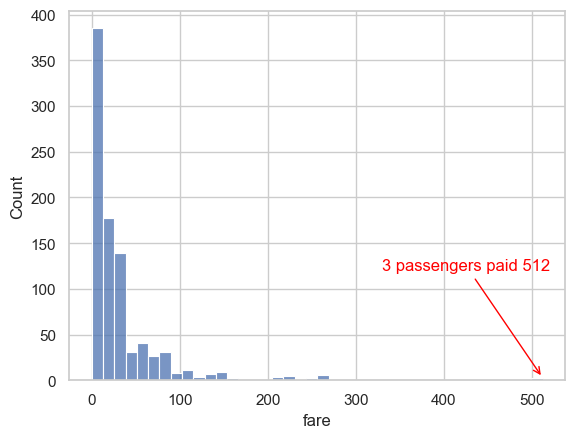

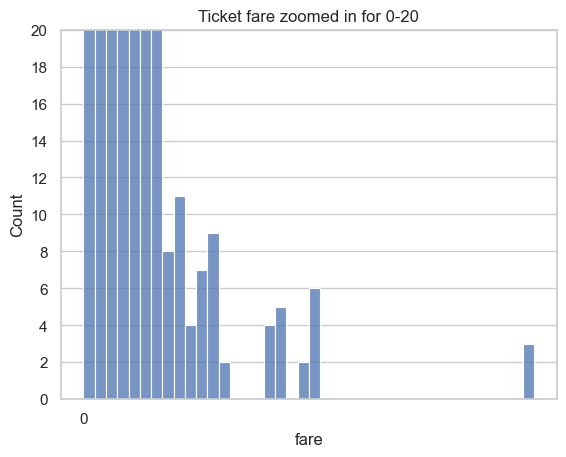

In [29]:
sns.histplot(data=df, x='fare', bins=40)
plt.annotate('3 passengers paid 512',
             xy=(512,3),
             xytext=(330,120),
             arrowprops=dict(arrowstyle="->", color='red'),
             color='red'
             )
plt.show()
sns.histplot(data=df, x='fare', bins=40)
plt.ylim(0,20)
plt.yticks(range(0,21,2))
plt.xticks(range(0,551,5000))
plt.title('Ticket fare zoomed in for 0-20')
plt.show()

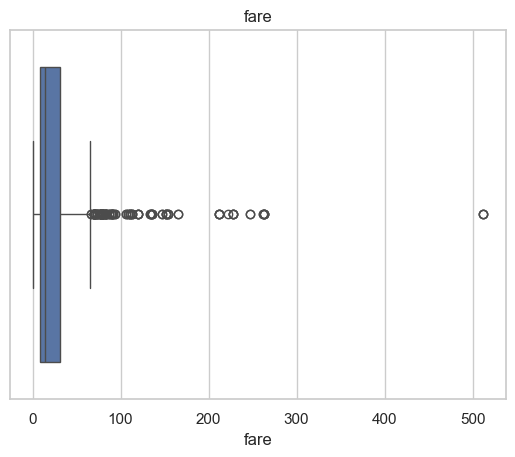

In [32]:
sns.boxplot(data=df,x='fare')
plt.title('fare')
plt.show()

In [41]:
q1 =df['fare'].quantile(0.25)
q3 =df['fare'].quantile(0.75)
iqr = q3 - q1
high = q3 +1.5 *iqr
# low = q1 -1.5 * iqr
outliers =df[df['fare']>high]
outliers.sort_values('fare', ascending=False).head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked,alone,family_size,age_group,is_female,fare_per_person
258,1,1,female,35.0,0,0,512.3292,C,True,1,Adult,1,512.329200
737,1,1,male,35.0,0,0,512.3292,C,True,1,Adult,0,512.329200
679,1,1,male,36.0,0,1,512.3292,C,False,2,Adult,0,256.164600
27,0,1,male,19.0,3,2,263.0000,S,False,6,Adult,0,43.833333
341,1,1,female,24.0,3,2,263.0000,S,False,6,Adult,1,43.833333


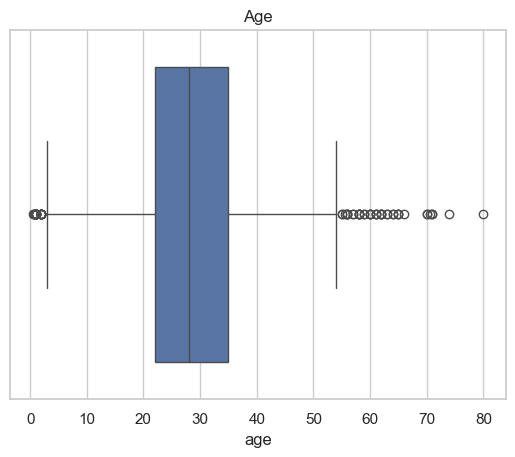

In [42]:
sns.boxplot(data=df, x='age')
plt.title("Age")
plt.show()

In [54]:
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3 -q1
high = q3 + 1.5 * iqr
low = q1 -1.5 *iqr
outliers_high = df[df['age']>high]
outliers_low = df[df['age']<low]
# outliers_low.sort_values('age', ascending=False).head()
# outliers_high.sort_values('age',ascending=False).head()
age_out = df[(df['age'] <low)| (df['age']>high)]
print("outliers ", len(age_out))

outliers  66


In [56]:
outliers_low.sort_values('age', ascending=False).head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked,alone,family_size,age_group,is_female,fare_per_person
7,0,3,male,2.0,3,1,21.0750,S,False,5,Child,0,4.215000
16,0,3,male,2.0,4,1,29.1250,Q,False,6,Child,0,4.854167
119,0,3,female,2.0,4,2,31.2750,S,False,7,Child,1,4.467857
205,0,3,female,2.0,0,1,10.4625,S,False,2,Child,1,5.231250
530,1,2,female,2.0,1,1,26.0000,S,False,3,Child,1,8.666667


In [ ]:
outliers_high.sort_values('age',ascending=False).head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked,alone,family_size,age_group,is_female,fare_per_person
630,1,1,male,80.0,0,0,30.0000,S,True,1,Adult,0,30.0000
851,0,3,male,74.0,0,0,7.7750,S,True,1,Adult,0,7.7750
96,0,1,male,71.0,0,0,34.6542,C,True,1,Adult,0,34.6542
493,0,1,male,71.0,0,0,49.5042,C,True,1,Adult,0,49.5042
116,0,3,male,70.5,0,0,7.7500,Q,True,1,Adult,0,7.7500


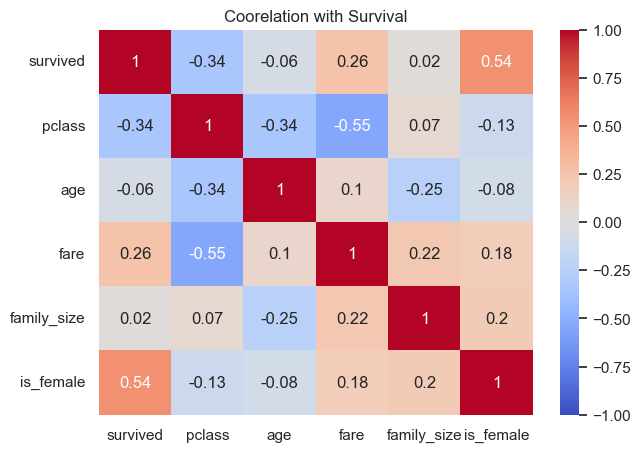

In [65]:
cols = ["survived", "pclass", "age", "fare", "family_size", "is_female"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr().round(2),annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Coorelation with Survival")
plt.show()

In [66]:
print("Overall survival rate:", round(df["survived"].mean() * 100), "%")
print(df.groupby("gender")["survived"].mean().round(2))

Overall survival rate: 38 %
gender
female    0.74
male      0.19
Name: survived, dtype: float64


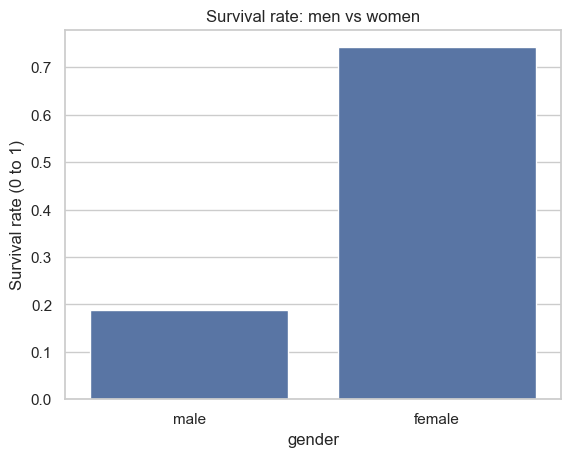

In [ ]:
sns.barplot(data=df, x="gender", y="survived", errorbar=None)
plt.title("Survival rate: men vs women")
plt.ylabel("Survival rate (0 to 1)")
# plt.savefig("survival_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()

pclass
1    0.63
2    0.47
3    0.24
Name: survived, dtype: float64


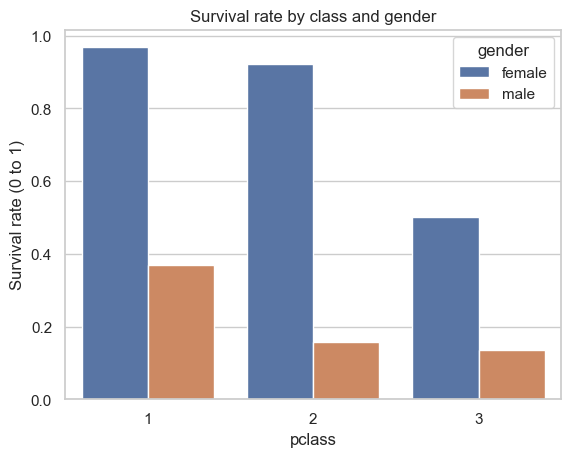

In [68]:
print(df.groupby("pclass")["survived"].mean().round(2))

sns.barplot(data=df, x="pclass", y="survived", hue="gender", errorbar=None)
plt.title("Survival rate by class and gender")
plt.ylabel("Survival rate (0 to 1)")
plt.savefig("survival_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

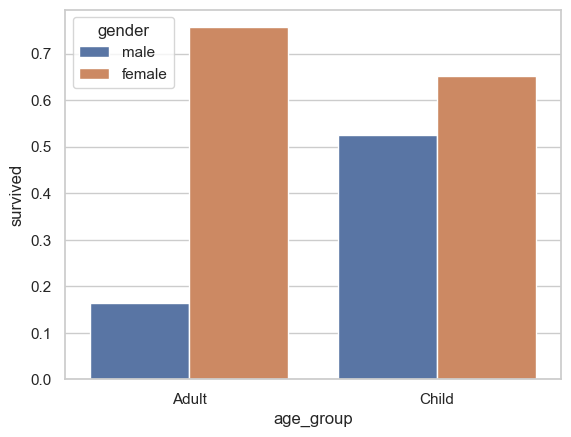

In [70]:
sns.barplot(data=df, x='age_group', y='survived',hue="gender", errorbar=None)
plt.show()